In [1]:
# https://pytorch.org/tutorials/intermediate/char_rnn_classification_tutorial.html# 
# https://karpathy.github.io/2015/05/21/rnn-effectiveness/
# https://pytorch.org/tutorials/intermediate/char_rnn_generation_tutorial.html
# https://pytorch.org/tutorials/intermediate/seq2seq_translation_tutorial.html

# Guión de prácticas: Entrenando una RNN básica

**Asignatura**: Deep Learning para procesamiento de Lenguaje Natural, 2026/2027

**Profesor**: Juan A. Botía (juanbot@um.es)

**Máster de Inteligencia Artificial**

**Facultad de Informática**

![](https://www.um.es/image/layout_set_logo?img_id=175281&t=1726728636242)

**Universidad de Murcia**

![](https://www.um.es/o/um-lr-principal-um-home-theme/images/logo-um.png)



# Introducción

Vamos a usar RNNs (Recurrent Neural Networks) para **leer palabras en forma de secuencia de caracteres con las que generar una predicción en forma de etiqueta y un estado oculto en $h_t$ en cada paso**.

Nuestra tarea es determinar en qué lengua se usa un nombre que introducimos a nuestro modelo.

Esta parte está adaptada de este [tutorial de Pytorch](https://pytorch.org/tutorials/intermediate/char_rnn_classification_tutorial.html). 

## Obteniendo los datos de aprendizaje

Para este tutorial, tenemos nuestros propios datos de aprendizaje, que vienen de 18 ficheros de texto, cada uno correspondiente a una lengua determinada y con ejemplos de nombres típicos de esa lengua. 

Lo que haremos será, en código, leer cada uno de esos ficheros, y representarlos internamente como un diccionario de listas de palabras con una entrada en el diccionario para cada lengua. 

Los datos se descargan [aquí](https://download.pytorch.org/tutorial/data.zip). Lo haremos desde código usando requests para peticiones desde HTTP, luego zipfile para gestionar compresión.

In [2]:
import requests
import zipfile
import os
import glob
import unicodedata
import string


url = 'https://download.pytorch.org/tutorial/data.zip'

print("El directorio actual es " + os.getcwd())
# Local folder where the zip file will be saved
download_folder = './'  # Replace with your desired folder
zip_file_path = os.path.join(download_folder, 'data.zip')

# Step 1: Download the zip file
response = requests.get(url)
open(zip_file_path,'wb').write(response.content)


# Step 2: Extract the zip file
zipfile.ZipFile(zip_file_path, 'r').extractall(download_folder)

# Optionally, you can remove the zip file after extraction
os.remove(zip_file_path)

print(f'File downloaded and extracted to {download_folder}')


def findFiles(path): return glob.glob(path)

print(findFiles(download_folder + '/data/names/*.txt'))

all_letters = string.ascii_letters + " .,;'"
n_letters = len(all_letters)

# Turn a Unicode string to plain ASCII, thanks to https://stackoverflow.com/a/518232/2809427
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in all_letters
    )

print(unicodeToAscii('Ślusàrski'))

# Build the category_lines dictionary, a list of names per language
category_lines = {}
all_categories = []

# Read a file and split into lines
def readLines(filename):
    lines = open(filename, encoding='utf-8').read().strip().split('\n')
    return [unicodeToAscii(line) for line in lines]

for filename in findFiles(download_folder + '/data/names/*.txt'):
    category = os.path.splitext(os.path.basename(filename))[0]
    all_categories.append(category)
    lines = readLines(filename)
    category_lines[category] = lines

n_categories = len(all_categories)

El directorio actual es /Users/juanbot/locclases/locdlpln20252026/pytorch
File downloaded and extracted to ./
['.//data/names/Czech.txt', './/data/names/German.txt', './/data/names/Arabic.txt', './/data/names/Japanese.txt', './/data/names/Chinese.txt', './/data/names/Vietnamese.txt', './/data/names/Russian.txt', './/data/names/French.txt', './/data/names/Irish.txt', './/data/names/English.txt', './/data/names/Spanish.txt', './/data/names/Greek.txt', './/data/names/Italian.txt', './/data/names/Portuguese.txt', './/data/names/Scottish.txt', './/data/names/Dutch.txt', './/data/names/Korean.txt', './/data/names/Polish.txt']
Slusarski


Después de esto hemos conseguido en la variable `category_lines` un diccionario que mapea cada idioma a  una lista de nombres propios. En `all_categories` tenemos todos los idiomas consideramos y su número en `n_categories`, como podemos ver según

In [3]:
print(category_lines['Italian'][:5])

['Abandonato', 'Abatangelo', 'Abatantuono', 'Abate', 'Abategiovanni']


## Codificando nombres en forma de tensores

Necesitamos representar los nombres en forma de tensores. 

* La unidad mínima de información para nosotros es el carácter. 

* Debemos codificar cada carácter en un tensor. 

Podríamos ...

* Una palabra es una secuencia de caracteres: bastaría con pensar en usar un número para cada letra del abecedario. 

* Podríamos usar la posición del abecedario para cada letra. Así, la A sería el 1, y la B el 2, y así sucesivamente. 

* Representaríamos una letra con un vector de longitud variable de posiciones en el abecedario. 

¿Es buena esta solución? ¿Por qué? Tip: estamos añadiendo a la codificación de la palabra un nivel de codificación adicional (la posición de la letra en el diccionario).

¿Y si usamos one-hot?

* codificando una palabra con tantos bits como letras distintas en nuestro abecedario reservando un solo bit a 1, en la posición reservada a esa letra. 

* ¿Y cómo codificar palabras enteras? Reservando un vector para cada letra en el tensor.

Para gestionar esta cofificación necesitaremos convertir 

* de letra a índice, 

* convertir de letra a tensor, y 

+ de texto a tensor de letras one-hot.

In [4]:
import torch

# Convierte de letra a índice e.g. "a" = 0
def letterToIndex(letter):
    return all_letters.find(letter)

# Converte letra en tensor <1 x n_letters> 
def letterToTensor(letter):
    tensor = torch.zeros(1, n_letters)
    tensor[0][letterToIndex(letter)] = 1
    return tensor

# Convierte una línea de texto en un tensor de dimensiones
#  <line_length x 1 x n_letters>, que es un array de vectores
# de tipo one-hot
def lineToTensor(line):
    tensor = torch.zeros(len(line), 1, n_letters)
    for li, letter in enumerate(line):
        tensor[li][0][letterToIndex(letter)] = 1
    return tensor

print(letterToTensor('J'))

print(lineToTensor('Juan').size())

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0.]])
torch.Size([4, 1, 57])


## Definición de la RNN

Recordemos que para que la red neuronal recurrente realice una predicción, necesita de la entrada actual $x_t$, y del estado oculto producido en el estado anterior, $h_{t-1}$, y con eso produce la predicción $o_t$, y el estado oculto $h_t$. 

En esencia, toda la lógica desde el punto de vista de la programación se ha de concentrar entonces en definir los parámetros que acepta cada capa de la red, y en cómo la función `forward()` realiza las llamadas para que la información sobre recursión fluya adecuadamente. 

Vamos a verlo.


In [5]:
import torch.nn as nn
import torch.nn.functional as F

class RNN(nn.Module):
    # Como podemos ver, ahora gestionamos el estado oculto
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN, self).__init__()

        self.hidden_size = hidden_size

        #La red es un MLP de dos capas
        #Hasta aquí, idéntico a un MLP
        self.i2h = nn.Linear(input_size, hidden_size)
        self.h2h = nn.Linear(hidden_size, hidden_size)
        self.h2o = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input, hidden):
        #En la variable hidden es donde se genera el estado oculto
        #que se usa como recurrencia
        hidden = F.tanh(self.i2h(input) + self.h2h(hidden))
        output = self.h2o(hidden)
        output = self.softmax(output)
        return output, hidden

    def initHidden(self):
        return torch.zeros(1, self.hidden_size)

n_hidden = 128
rnn = RNN(n_letters, n_hidden, n_categories)

for name, param in rnn.named_parameters():
    print(f"Nombre del parámetro {name} y tamaño {rnn.get_parameter(name).data.shape}")

Nombre del parámetro i2h.weight y tamaño torch.Size([128, 57])
Nombre del parámetro i2h.bias y tamaño torch.Size([128])
Nombre del parámetro h2h.weight y tamaño torch.Size([128, 128])
Nombre del parámetro h2h.bias y tamaño torch.Size([128])
Nombre del parámetro h2o.weight y tamaño torch.Size([18, 128])
Nombre del parámetro h2o.bias y tamaño torch.Size([18])


Como se ve, hemos inicializado una red con 128 nodos ocultos en su capa intermedia. ¿Cómo usaríamos ahora la red?

Dado un nombre, por ejemplo "Alberto", lo convertiríamos a tensor como ya hemos programado hacer, al llamar inicialmente a la red recurrente, el estado $h_0$ sería un tensor a 1's, del tamaño de los nodos ocultos, y le pasaríamos la primera letra de la entrada, como sigue



In [6]:
input = lineToTensor('Albert')
hidden = torch.zeros(1, n_hidden)

output, next_hidden = rnn(input[0], hidden)
print(output)
output.shape

tensor([[-2.8734, -2.8718, -2.8246, -2.9489, -2.9855, -2.8828, -3.0705, -2.8490,
         -2.8220, -2.9193, -2.9094, -2.9681, -2.8200, -2.9231, -2.8633, -2.8179,
         -2.8192, -2.8971]], grad_fn=<LogSoftmaxBackward0>)


torch.Size([1, 18])

Como vemos, se devuelve un tensor con 18 valores, correspondientes a la verosimilitud de que el nombre se ajuste a cada una de las 18 lenguas que estamos considerando. Y, como es natural, la apariencia de esos valores es aleatoria ya que la red está inicializada aleatoriamente y no está tomando decisión con sentido alguno. Necesitamos entrenarla.

Pero antes de entrenarla, necesitamos alguna función que nos ayude a entender mejor la salida de la red. 

* Necesitaremos obtener el índice correspondiente al valor del tensor con la verosimilitud máxima para obtener la lengua. Nos basamos en la función `Tensor.topk()` y en haber definido como global la variable `all_categories`.

In [7]:
def output2Idioma(output):
    #La función topk(1) devuelve el primer 
    # mayor elemento del vector
    top_n, top_i = output.topk(1)
    idioma_i = top_i[0].item()
    return all_categories[idioma_i], idioma_i

print(output2Idioma(output))

('Dutch', 15)


## Estrategia para acceso a los datos

Para entrenar la red, necesitamos elaborar una estrategia para recorrer los datos de training.

* Vamos a **muestrear aleatoriamente de manera uniforme** tanto en las lenguas como, en cada lengua, a lo largo de los nombres. 

* Definiremos una función básica que elija un elemento aleatoriamente dentro de un vector, y este será el elemento básico para movernos a lo largo de las lenguas y sus nombres. Una vez escogido, devolveremos todas sus versiones, en crudo y codificado en forma de tensor.

In [8]:
import random

def randomChoice(l):
    return l[random.randint(0, len(l) - 1)]

def randomTrainingExample():
    category = randomChoice(all_categories)
    line = randomChoice(category_lines[category])
    category_tensor = torch.tensor([all_categories.index(category)], dtype=torch.long)
    line_tensor = lineToTensor(line)
    return category, line, category_tensor, line_tensor

for i in range(10):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    print('category =', category, '/ line =', line)

category = Portuguese / line = Souza
category = Portuguese / line = Rios
category = Portuguese / line = Torres
category = Czech / line = Oborny
category = French / line = Jordan
category = Italian / line = Lupo
category = Dutch / line = Kolen
category = French / line = Richard
category = Vietnamese / line = Chau
category = English / line = Mcleod


Como vemos, funciona perfectamente.

## Estrategia para el entrenamiento

Recordemos que para pensar en cómo entrenar la red, debemos pensar en dos elementos principales: **la función de pérdida** por un lado y **el algoritmo de entrenamiento** de los parámetros $\theta$ de la red. En realidad hay muchos más detalles a tener en cuenta si queremos realizar un trabajo a fondo pero todos esos detalles los veremos en la asignatura de Machine Learning. 

En clase ya hemos visto que para problemas de 2 o más clases, la función de pérdida básica es la de la *negative log likelihood* o verosimilitud logarítmica negativa. Esta es la `torch.nn.NLLLoss` (ver detalles [aquí](https://pytorch.org/docs/stable/generated/torch.nn.NLLLoss.html)).

Ahora debemos pensar cuidadosamente en qué ocurre internamente en la red con cada ejemplo. Un ejemplo en este caso es un nombre, básicamente una secuencia de letras. Y cada letra es la fila de un tensor bidimensional que se trata individualmente. De izquierda a derecha, siguiendo el orden de los caracteres. Pero ¿cómo nos aseguramos de eso? Llamando a `rnn()` secuencialmente con cada uno de los caracteres de la palabra, y el correspondiente estado oculto. Por ejemplo, para el nombre `Eva`, la secuencia de caracteres sería $x_1=E$, $x_2=v$ y $x_3=a$. Y la secuencia de estados ocultos $h_0=1$, $h_1$, ... Y haríamos

```python
for i in range(line_tensor.size()[0]):
        output, hidden = rnn(line_tensor[i], hidden)
```

Iteramos sobre el número de filas del tensor. Accedemos a cada fila en cada llamada a `rnn()`, y le pasamos además el estado oculto de la llamada anterior. Obsérvese que `output` la ignoramos hasta la última llamada ya que, realmente, solo nos interesa su valor cuando ha finalizado de procesar la palabra entera. 

Una vez procesada la palabra, calculamos la pérdida, llamamos a `backward()` sobre esa pérdida y después de eso, los gradientes ya están listos para añadirlos a sus parámetros. Con todo esto, ya estamos listos para entender la función `train()` que definimos 


In [9]:
import torch.optim as optim
learning_rate = 0.005
criterion = nn.NLLLoss()
optimizer = optim.SGD(rnn.parameters(),learning_rate)

def train(category_tensor, line_tensor):
    hidden = rnn.initHidden()

    rnn.zero_grad()

    for i in range(line_tensor.size()[0]):
        output, hidden = rnn(line_tensor[i], hidden)

    loss = criterion(output, category_tensor)
    loss.backward()
    optimizer.step()
    # Add parameters' gradients to their values, multiplied by learning rate
    #for p in rnn.parameters():
    #    p.data.add_(p.grad.data, alpha=-learning_rate)

    return output, loss.item()

Lo que necesitamos ahora es monitorizar el aprendizaje, algo en realidad bastante rutinario que se necesita en todo experimento. Piénsese que necesitamos un bucle que esté repetidamente enseñando ejemplos a la red neuronal y para cada ejemplo, calcule la pérdida, y se propaguen los gradientes, estos se usen para actualizar los pesos y con eso la red cambie. 

Al cambiar la red, esta se comportará de esa forma. ¿Cómo medimos si ha cambiado? ¿Y cómo lo hacemos dinámicamente mientras efectuamos el proceso de aprendizaje?

Lo primero en que hemos de pensar es en qué medir. Y luego en cómo medirlo y en qué momento medirlo para reportarlo. Lo evidente es que necesitamos medir la pérdida. Y reportarla dinámicamente, conforme se va actualizando.

Por otro lado, también resulta más o menos claro que si lo que hacemos es predecir idiomas para nombres, sería un buen indicador imprimir para cada ejemplo el idioma correcto y el predicho. Sin embargo, si para cada ejemplo hacemos esto, vamos a inundar la consola con un número excesivo e innecesario de mensajes dejando aparte el hecho de que vamos a consumir excesivo tiempo innecesario que podríamos estar usando para en entrenamiento. Lo que haremos es actualizar las notificaciones cada cierto tiempo.

Imprimiremos cada 5000 ejemplos y plotearemos la pérdida cada 1000.

In [10]:
import time
import math

n_iters = 100000
print_every = 5000
plot_every = 1000



# Keep track of losses for plotting
current_loss = 0
all_losses = []

def timeSince(since):
    now = time.time()
    s = now - since
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

start = time.time()

for iter in range(1, n_iters + 1):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    output, loss = train(category_tensor, line_tensor)
    current_loss += loss

    # Print ``iter`` number, loss, name and guess
    if iter % print_every == 0:
        guess, guess_i = output2Idioma(output)
        correct = '✓' if guess == category else '✗ (%s)' % category
        print('%d %d%% (%s) %.4f %s / %s %s' % (iter, iter / n_iters * 100, timeSince(start), loss, line, guess, correct))

    # Add current loss avg to list of losses
    if iter % plot_every == 0:
        all_losses.append(current_loss / plot_every)
        current_loss = 0

5000 5% (0m 8s) 2.1418 Okazawaya / Italian ✗ (Japanese)
10000 10% (0m 15s) 1.5762 Mathghamhain / Irish ✓
15000 15% (0m 23s) 1.8135 Teoh / Korean ✗ (Chinese)
20000 20% (0m 30s) 1.3608 Rusnak / Czech ✗ (Polish)
25000 25% (0m 38s) 0.6809 Fernandes / Portuguese ✓
30000 30% (0m 45s) 2.3256 Cerney / English ✗ (Czech)
35000 35% (0m 54s) 0.2934 Xing / Chinese ✓
40000 40% (1m 2s) 0.5568 Nagano / Japanese ✓
45000 45% (1m 10s) 1.2198 Lefebvre / French ✓
50000 50% (1m 18s) 0.6835 O'Neal / Irish ✓
55000 55% (1m 25s) 0.1856 Robertson / Scottish ✓
60000 60% (1m 33s) 0.3037 Milionis / Greek ✓
65000 65% (1m 41s) 0.6213 Daniau / French ✓
70000 70% (1m 49s) 1.5973 Pan / Vietnamese ✗ (Chinese)
75000 75% (1m 56s) 0.5665 D'cruz / Portuguese ✓
80000 80% (2m 4s) 1.4386 Shamon / Arabic ✓
85000 85% (2m 12s) 0.5424 Carbone / Italian ✓
90000 90% (2m 19s) 0.0060 Maslanka / Polish ✓
95000 95% (2m 27s) 0.1165 Ungaretti / Italian ✓
100000 100% (2m 35s) 0.0295 Arvanitoyannis / Greek ✓


Hemos necesitado dos minutos y medio en un MacBook Pro i7 2.6GHz 32GB.
Realmente, con esto no estamos seguros de qué está pasando ya que lo que estamos viendo no nos dice realmente nada. Todos esos casos son puntuales, con fallos y aciertos repartidos aparentemente por igual. Plotear la pérdida nos dirá algo con más seguridad.


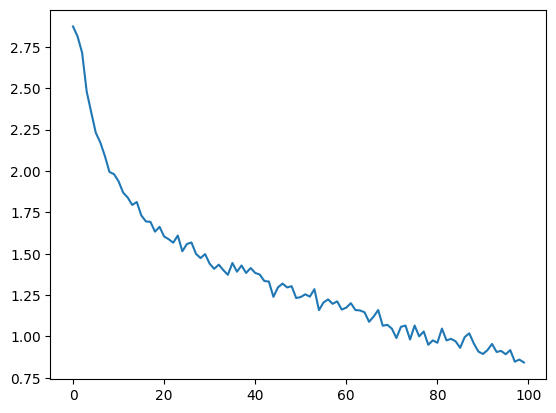

In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure()
plt.plot(all_losses)

Efectivamente. El error de entrenamiento baja de forma constante, lo cual es de esperar en un algoritmo del tipo de SGD al menos con lo ejemplos de entrenamiento. 

Algo interesante en lo que no hemos reparado es en la similitud entre idiomas y, por tanto, entre nombres, debido a las diferentes raíces de cada lengua ya sean latinas, como el portugués y el castellano, o germánicas como el alemán y el holandés. Eso podemos comprobarlo con una matriz de confusión en la que podemos plotear profusamente cómo se distribuyen las predicciones incorrectas de nuestro modelo, i.e., cuando indica que un nombre proviene de una lengua incorrecta, en qué porcentaje predice cada una de las lenguas incorrectas. 

Esto es interesante porque podemos ver más en detalle si cuando se equivoca el clasificador lo hace prediciendo una lengua de la misma raíz que la correcta y, por tanto, el fallo podría verse como leve o lo hace de forma aleatoria asignando, por ejemplo, un idioma de raíz oriental a un nombre portugués. 

Esto lo conseguimos con una matriz $m[i,j]$ en la que con $j$ hacemos referencia a la lengua de la predicción y con $i$ a la lengua correcta del nombre correspondiente. Tal que en $m[i,i]$ tenemos la cantidad de ejemplos predichos como $i$ cuando en realidad eraun ejemplo de la lengua $i$ y en $m[i,j]$ la cantidad de ejemplos que se predicen de $j$ cuando en realidad eran de la lengua $i$.   

Para ello, una vez la red está entrenada, vamos a escoger aleatoriamente 10000 de los ejemplos que habremos usado previsiblemente para entrenar y los usaremos para crear esa matriz. 



/var/folders/4y/g7sdw7952490zrjb6x3j_sb40000gn/T/ipykernel_54854/1900406250.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + all_categories, rotation=90)
/var/folders/4y/g7sdw7952490zrjb6x3j_sb40000gn/T/ipykernel_54854/1900406250.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + all_categories)


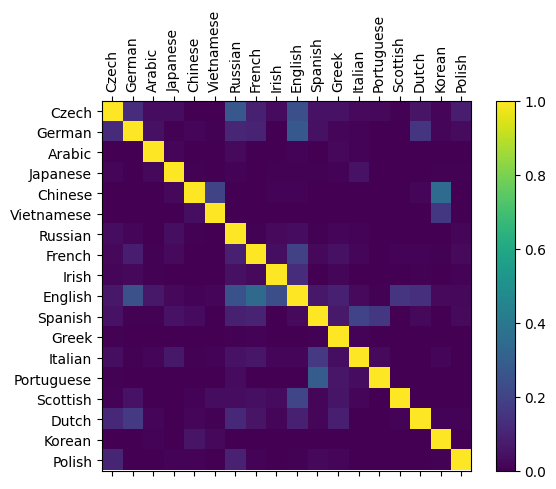

In [12]:
# creamos una matriz cuadrada, de lenguas en filas (correctas) y 
# y columnas (predichas) 
confusion = torch.zeros(n_categories, n_categories)
n_confusion = 10000

# Dado un nombre ya codificado, genera la predicción de la red
def evaluate(line_tensor):
    hidden = rnn.initHidden()

    for i in range(line_tensor.size()[0]):
        output, hidden = rnn(line_tensor[i], hidden)

    return output

# Iteramos sobre los 10K ejemplos y actualizamos las celdas
# de la matriz de confusión según la predicción y la etiqueta
# correcta
for i in range(n_confusion):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    output = evaluate(line_tensor)
    guess, guess_i = output2Idioma(output)
    category_i = all_categories.index(category)
    # actualizamos la celda correspondiente
    confusion[category_i][guess_i] += 1

# Escalamos entre [0,1]
for i in range(n_categories):
    confusion[i] = confusion[i] / confusion[i].max()

# Ahora ploteamos
fig = plt.figure()
ax = fig.add_subplot(111)
# El tipo de plot es específico de una matriz
cax = ax.matshow(confusion.numpy())
fig.colorbar(cax)

# Lenguas en los ejes
ax.set_xticklabels([''] + all_categories, rotation=90)
ax.set_yticklabels([''] + all_categories)

# Con estas llamadas conseguimos los ticks en cada celda x, y
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

plt.show()

Un análisis pormenorizado de la matriz de confusión revela cosas interesantes. 

* La diagonal muestra valores muy próximos al 1 aunque no del todo ya que el resto de celdas de las cada una de las filas cotiene al menos una celda con color no oscuro del todo. 

* El alemán, el checo, el holandés y el polaco muestran coincidencias.

* El inglés muestra confusión (coincidencias) con muchos otros lenguajes.

* El castellano y el portugués muestran una de las coincidencias más fuertes así como el chino y el vietnamita.

